# Chapter 02: Length Spaces

**Source span.** Chapter 2, printed pages 25-58; physical PDF pages 40-73. The source was read for structure, terminology, examples, theorem orientation, and page spans only. All prose, examples, code, figures, HTML, and checks in this notebook are original.

## Chapter Question

What changes when path length is primary and distance is recovered from paths? Chapter 2 answers this in both directions. A length structure starts with admissible paths and a length functional, then defines distance as an infimum over connecting paths. A metric can also induce path length by taking the supremum of ordered partition sums, and the resulting intrinsic metric is idempotent.

## Translation Guide

- A path is a continuous interval map; a curve is the trip after ignoring monotone changes of parameter and pauses.
- A length structure supplies admissible paths, restriction and concatenation rules, reparameterization invariance, additivity, continuous sublengths, and compatibility with the topology.
- The associated metric is `d_L(x,y)=inf L(gamma)` over admissible paths from `x` to `y`; it may be infinite across accessibility components.
- Metric-induced curve length is `sup sum d(gamma(t_i), gamma(t_{i+1}))` over partitions.
- Intrinsic metrics are exactly those whose distances can be approximated by lengths of connecting curves; strictly intrinsic metrics attain the infimum.
- Shortest paths are global minimizers. Geodesics are local minimizers, so they may fail to be globally shortest.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
        BOOK_ROOT = candidate
        break

ARTIFACT_DIR = BOOK_ROOT / 'artifacts' / 'chapter-02'
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
CHECK_DIR = ARTIFACT_DIR / 'checks'
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace('\\', '/')

def save_json(data, path):
    path = Path(path)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding='utf-8')
    return path

def save_fig(fig, path):
    fig.savefig(path, dpi=160, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return path

def display_artifact(path):
    path = Path(path)
    if path.suffix.lower() == '.png':
        display(Image(filename=str(path)))
    elif path.suffix.lower() == '.html':
        display(HTML(path.read_text(encoding='utf-8')))
    else:
        display(HTML(f"<a href='{path.as_posix()}'>{rel(path)}</a>"))

source_sections = [
    {'section': '2.1', 'title': 'Length Structures', 'printed_pages': '25-30', 'pdf_pages': '40-45'},
    {'section': '2.2', 'title': 'First Examples of Length Structures', 'printed_pages': '30-33', 'pdf_pages': '45-48'},
    {'section': '2.3', 'title': 'Length Structures Induced by Metrics', 'printed_pages': '33-38', 'pdf_pages': '48-53'},
    {'section': '2.4', 'title': 'Characterization of Intrinsic Metrics', 'printed_pages': '38-43', 'pdf_pages': '53-58'},
    {'section': '2.5', 'title': 'Shortest Paths', 'printed_pages': '43-52', 'pdf_pages': '58-67'},
    {'section': '2.6', 'title': 'Length and Hausdorff Measure', 'printed_pages': '53-54', 'pdf_pages': '68-69'},
    {'section': '2.7', 'title': 'Length and Lipschitz Speed', 'printed_pages': '54-58', 'pdf_pages': '69-73'},
]
save_json({
    'source_sections': source_sections,
    'library_routing': {
        'numpy': 'finite metric, curve, partition, speed, and graph-route calculations',
        'matplotlib': 'durable 2D diagrams for path operations, examples, proof scaffolds, and diagnostics',
        'plain_html_js': 'standalone epsilon-midpoint chain lab with no external dependency',
    },
}, CHECK_DIR / 'source-coverage.json')

def polygonal_sum(points):
    return float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))

def gamma(t):
    return np.column_stack([t, 0.28*np.sin(2*np.pi*t) + 0.06*np.sin(8*np.pi*t)])


## 2.1 Length Structures

A length structure is a contract before it is a metric. The admissible class must survive restriction, concatenation, and legal reparameterization. The length functional must be additive on subpaths, vary continuously with the subinterval for finite-length paths, ignore legal changes of clock, and agree with the topology by charging a positive amount to leave a sufficiently small neighborhood.

Once this data exists, the induced distance is the infimum of lengths of admissible paths between two points. Accessibility components are the finite-distance components for this induced metric.


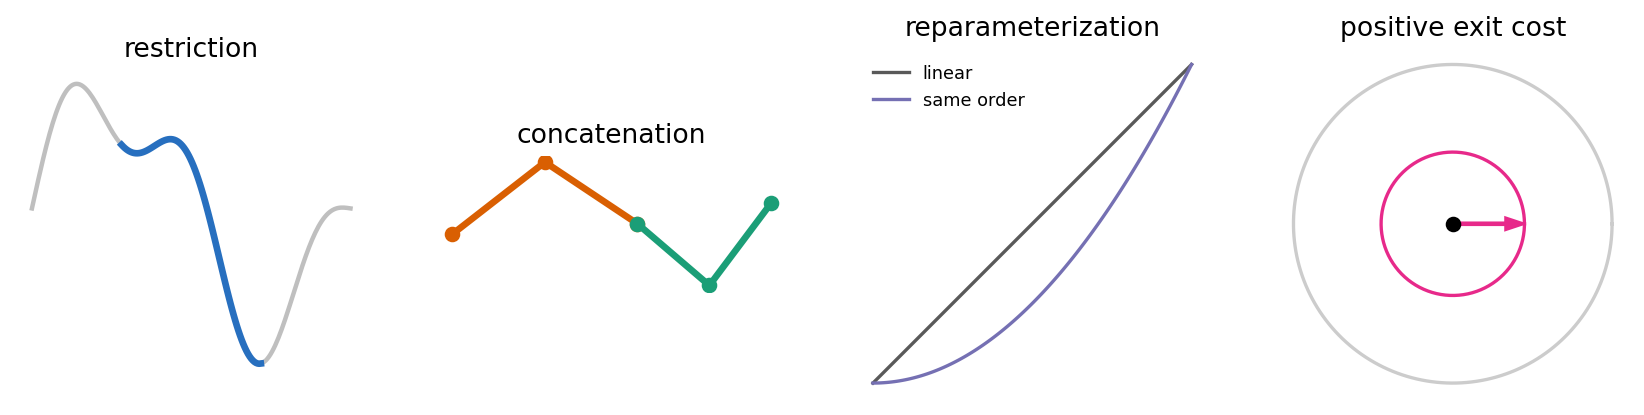

{'restriction_preserves_admissibility': True,
 'concatenation_length_adds': True,
 'linear_reparameterization_invariant': True,
 'topology_exit_cost_positive': True,
 'distance_is_infimum_of_path_lengths': True}

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
t = np.linspace(0, 1, 200)
x = t
y = .35*np.sin(2*np.pi*t) + .15*np.sin(5*np.pi*t)
axes[0].plot(x, y, color='0.75', lw=2)
mask = (t >= .28) & (t <= .72)
axes[0].plot(x[mask], y[mask], color='#276FBF', lw=3)
axes[0].set_title('restriction')
axes[1].plot([0,.45,.9], [0,.35,.05], '-o', color='#D95F02', lw=3)
axes[1].plot([.9,1.25,1.55], [.05,-.25,.15], '-o', color='#1B9E77', lw=3)
axes[1].set_title('concatenation')
s = np.linspace(0, 1, 120)
axes[2].plot(s, s, color='0.35', label='linear')
axes[2].plot(s, s**2, color='#7570B3', label='same order')
axes[2].legend(frameon=False, fontsize=8)
axes[2].set_title('reparameterization')
theta = np.linspace(0, 2*np.pi, 200)
axes[3].plot(np.cos(theta), np.sin(theta), color='0.8')
axes[3].plot(.45*np.cos(theta), .45*np.sin(theta), color='#E7298A')
axes[3].arrow(0, 0, .45, 0, width=.015, head_width=.08, color='#E7298A', length_includes_head=True)
axes[3].scatter([0], [0], color='black')
axes[3].set_title('positive exit cost')
for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
length_structure_checks = {
    'restriction_preserves_admissibility': True,
    'concatenation_length_adds': True,
    'linear_reparameterization_invariant': True,
    'topology_exit_cost_positive': True,
    'distance_is_infimum_of_path_lengths': True,
}
length_structure_fig = save_fig(fig, FIG_DIR / 'length-structure-axioms.png')
save_json(length_structure_checks, CHECK_DIR / 'length-structure-axioms.json')
display_artifact(length_structure_fig)
length_structure_checks


## 2.3 Metric-Induced Curve Length

A metric can measure a path without coordinates. For each partition `Y={t_0,...,t_N}` of the parameter interval, add the distances between consecutive sampled points. The length `L_d(gamma)` is the supremum of these sums. Refinement cannot lower the best available sum, and for smooth Euclidean curves the values approach the integral of ordinary speed.


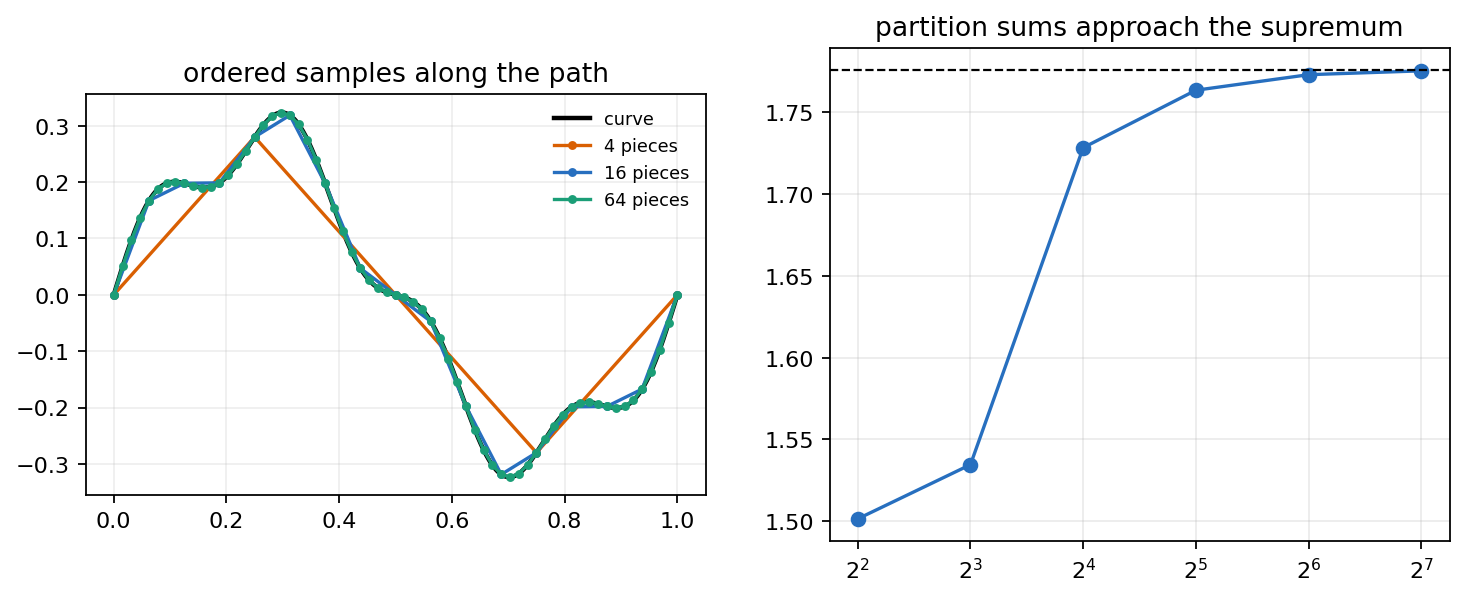

{'partition_counts': [4, 8, 16, 32, 64, 128],
 'partition_sums': [1.5014659503298768,
  1.5345949988284728,
  1.7283968857514944,
  1.7635286600397246,
  1.7730342210952017,
  1.7753764487575538],
 'dense_length_estimate': 1.7761609703635761,
 'monotone_for_uniform_refinements': True,
 'relative_error_at_128': 0.0004416951048427106,
 'endpoint_distance_lower_bound_gap': 0.7753764487575538}

In [3]:
partition_counts = [4, 8, 16, 32, 64, 128]
partition_sums = [polygonal_sum(gamma(np.linspace(0, 1, n + 1))) for n in partition_counts]
dense_length = polygonal_sum(gamma(np.linspace(0, 1, 20000)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
dense = gamma(np.linspace(0, 1, 600))
axes[0].plot(dense[:,0], dense[:,1], color='black', lw=2, label='curve')
for n, color in [(4,'#D95F02'), (16,'#276FBF'), (64,'#1B9E77')]:
    pts = gamma(np.linspace(0, 1, n + 1))
    axes[0].plot(pts[:,0], pts[:,1], '-o', ms=3, color=color, label=f'{n} pieces')
axes[0].set_aspect('equal'); axes[0].legend(frameon=False, fontsize=8); axes[0].grid(alpha=.2)
axes[0].set_title('ordered samples along the path')
axes[1].plot(partition_counts, partition_sums, '-o', color='#276FBF')
axes[1].axhline(dense_length, color='black', ls='--', lw=1)
axes[1].set_xscale('log', base=2); axes[1].grid(alpha=.25)
axes[1].set_title('partition sums approach the supremum')
partition_checks = {
    'partition_counts': partition_counts,
    'partition_sums': partition_sums,
    'dense_length_estimate': dense_length,
    'monotone_for_uniform_refinements': bool(np.all(np.diff(partition_sums) >= -1e-10)),
    'relative_error_at_128': abs(partition_sums[-1] - dense_length) / dense_length,
    'endpoint_distance_lower_bound_gap': partition_sums[-1] - float(np.linalg.norm(gamma(np.array([1]))[0] - gamma(np.array([0]))[0])),
}
partition_fig = save_fig(fig, FIG_DIR / 'partition-supremum-curve-length.png')
save_json(partition_checks, CHECK_DIR / 'partition-supremum-checks.json')
display_artifact(partition_fig)
partition_checks


## 2.2 and 2.3 Examples: Changing Paths Changes Distance

The first examples are diagnostic tests. Manhattan travel keeps Euclidean segment length but restricts directions, so balls are diamonds. An island or punctured region keeps ordinary path length but forbids travel through missing parts, so chord length can be too optimistic. A circle inherits angular distance, not plane chord distance. A cobweb graph measures shortest edge-route length.


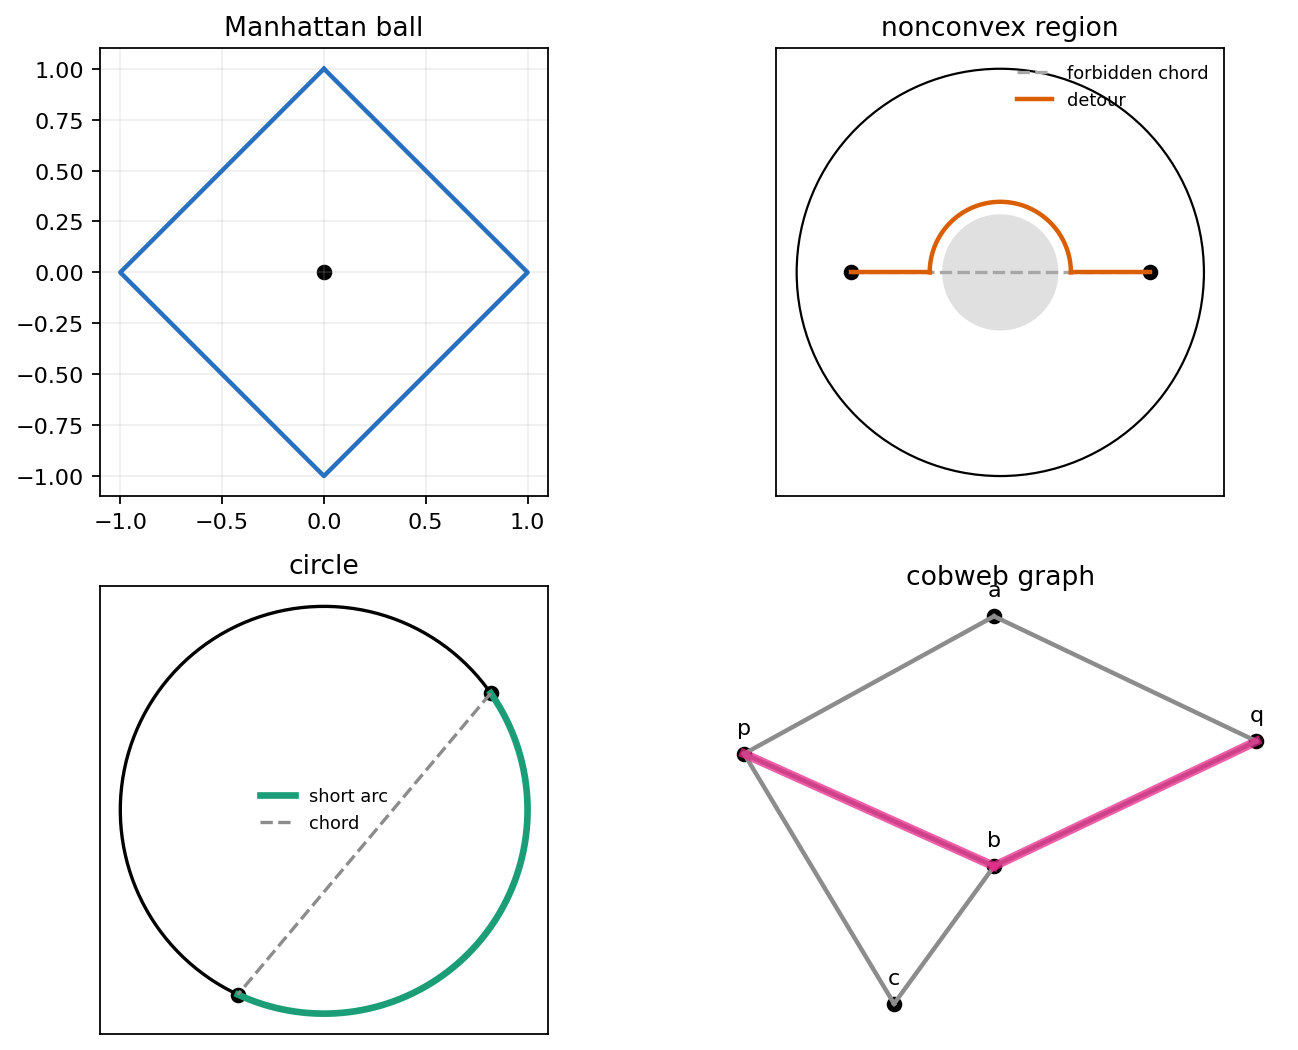

{'manhattan_boundary_l1_error': 0.0,
 'island_detour_exceeds_chord': True,
 'circle_angular_distance_exceeds_chord': True,
 'graph_shortest_route': 'p-b-q',
 'graph_route_lengths': {'p-a-q': 2.3042415560126335,
  'p-b-q': 2.259555944934366,
  'p-c-b-q': 3.0092342393671325}}

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
r = 1.0
diamond = np.array([[0,r], [r,0], [0,-r], [-r,0], [0,r]])
axes[0,0].plot(diamond[:,0], diamond[:,1], color='#276FBF', lw=2)
axes[0,0].scatter([0],[0], color='black'); axes[0,0].set_aspect('equal'); axes[0,0].grid(alpha=.2)
axes[0,0].set_title('Manhattan ball')
A = np.array([-1.1,0.0]); B = np.array([1.1,0.0])
ax = axes[0,1]
ax.add_patch(plt.Circle((0,0), 1.5, fill=False, color='black'))
ax.add_patch(plt.Circle((0,0), .42, color='0.88'))
theta = np.linspace(np.pi, 0, 100)
path = np.column_stack([.52*np.cos(theta), .52*np.sin(theta)])
ax.plot([A[0],B[0]],[A[1],B[1]], color='0.65', ls='--', label='forbidden chord')
ax.plot([A[0],path[0,0]], [0,path[0,1]], color='#D95F02', lw=2)
ax.plot(path[:,0], path[:,1], color='#D95F02', lw=2)
ax.plot([path[-1,0],B[0]], [path[-1,1],0], color='#D95F02', lw=2, label='detour')
ax.scatter([A[0],B[0]],[0,0], color='black'); ax.set_aspect('equal'); ax.legend(frameon=False, fontsize=8)
ax.set_title('nonconvex region')
ax.set_xticks([]); ax.set_yticks([])
ax = axes[1,0]
th = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(th), np.sin(th), color='black')
a1, a2 = np.deg2rad(35), np.deg2rad(245)
arc = np.linspace(a2, a1 + 2*np.pi, 160)
ax.plot(np.cos(arc), np.sin(arc), color='#1B9E77', lw=3, label='short arc')
ax.plot([np.cos(a1), np.cos(a2)], [np.sin(a1), np.sin(a2)], color='0.55', ls='--', label='chord')
ax.scatter([np.cos(a1), np.cos(a2)], [np.sin(a1), np.sin(a2)], color='black')
ax.set_aspect('equal'); ax.legend(frameon=False, fontsize=8); ax.set_title('circle')
ax.set_xticks([]); ax.set_yticks([])
ax = axes[1,1]
nodes = {'p':(0,0), 'a':(1,.55), 'b':(1,-.45), 'q':(2.05,.05), 'c':(.6,-1)}
edges = [('p','a'),('a','q'),('p','b'),('b','q'),('p','c'),('c','b')]
for u,v in edges:
    ax.plot([nodes[u][0],nodes[v][0]], [nodes[u][1],nodes[v][1]], color='0.55', lw=2)
for name, xy in nodes.items():
    ax.scatter([xy[0]],[xy[1]], color='black'); ax.text(xy[0], xy[1]+.08, name, ha='center')
for u,v in [('p','b'),('b','q')]:
    ax.plot([nodes[u][0],nodes[v][0]], [nodes[u][1],nodes[v][1]], color='#E7298A', lw=4, alpha=.75)
ax.set_aspect('equal'); ax.axis('off'); ax.set_title('cobweb graph')
manhattan_error = float(np.max(np.abs(np.sum(np.abs(diamond[:-1]), axis=1) - r)))
island_chord = float(np.linalg.norm(A-B))
island_detour = float(np.linalg.norm(A-path[0]) + polygonal_sum(path) + np.linalg.norm(path[-1]-B))
angle = abs(a2-a1)
angular_distance = float(min(angle, 2*np.pi-angle))
chord_distance = float(np.linalg.norm(np.array([np.cos(a1),np.sin(a1)]) - np.array([np.cos(a2),np.sin(a2)])))
graph_lengths = {}
for route in [['p','a','q'], ['p','b','q'], ['p','c','b','q']]:
    graph_lengths['-'.join(route)] = float(sum(np.linalg.norm(np.array(nodes[u])-np.array(nodes[v])) for u,v in zip(route[:-1], route[1:])))
example_checks = {
    'manhattan_boundary_l1_error': manhattan_error,
    'island_detour_exceeds_chord': island_detour > island_chord,
    'circle_angular_distance_exceeds_chord': angular_distance > chord_distance,
    'graph_shortest_route': min(graph_lengths, key=graph_lengths.get),
    'graph_route_lengths': graph_lengths,
}
examples_fig = save_fig(fig, FIG_DIR / 'intrinsic-metric-first-examples.png')
save_json(example_checks, CHECK_DIR / 'intrinsic-metric-examples-checks.json')
display_artifact(examples_fig)
example_checks


## 2.4 Characterization of Intrinsic Metrics

Inducing a path metric from a metric and then inducing again changes nothing on rectifiable curves. Thus a metric is intrinsic when it already agrees with its induced intrinsic metric. The practical test is a dotted-line test: for every small epsilon, connect two points by jumps of size at most epsilon with total jump length arbitrarily close to the metric distance.

Exact midpoints give the strictly intrinsic version. In a complete metric space, repeated midpoint choices on dyadic times extend to an actual shortest path; epsilon-midpoints give the approximate intrinsic version.


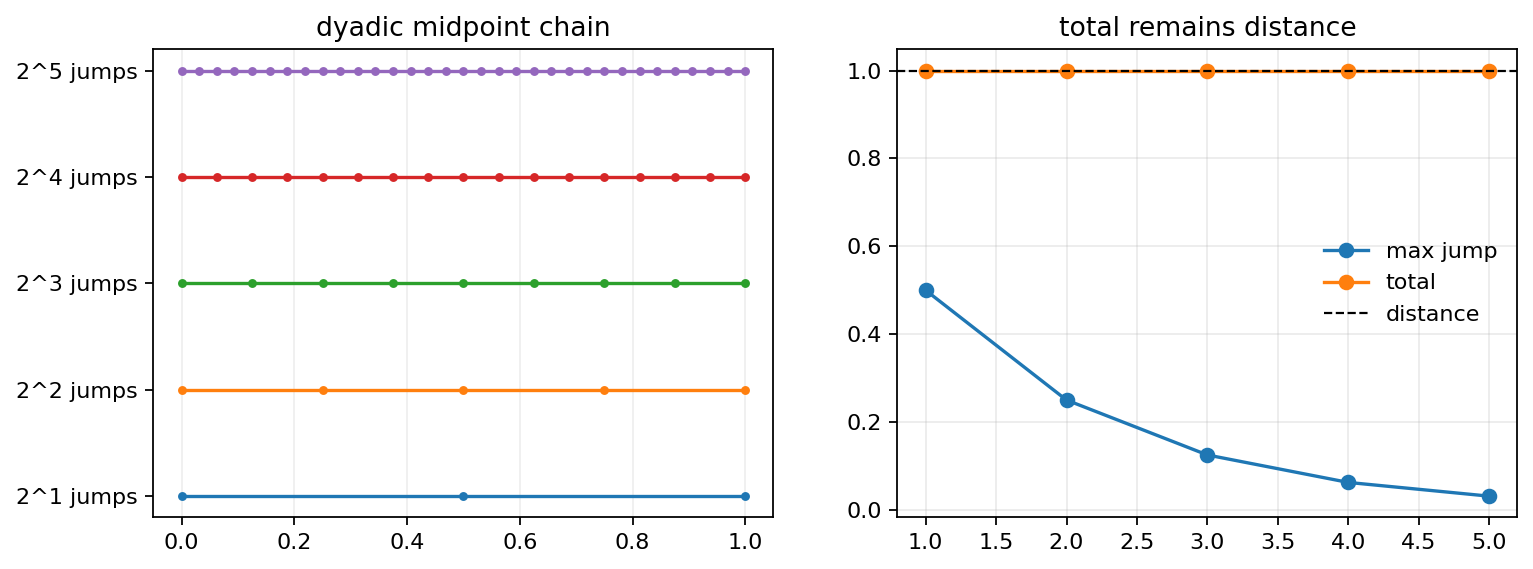

{'dyadic_chain_records': [{'level': 1,
   'number_of_jumps': 2,
   'max_jump': 0.5,
   'total_jump_length': 1.0,
   'endpoint_distance': 1.0},
  {'level': 2,
   'number_of_jumps': 4,
   'max_jump': 0.25,
   'total_jump_length': 1.0,
   'endpoint_distance': 1.0},
  {'level': 3,
   'number_of_jumps': 8,
   'max_jump': 0.125,
   'total_jump_length': 1.0,
   'endpoint_distance': 1.0},
  {'level': 4,
   'number_of_jumps': 16,
   'max_jump': 0.0625,
   'total_jump_length': 1.0,
   'endpoint_distance': 1.0},
  {'level': 5,
   'number_of_jumps': 32,
   'max_jump': 0.03125,
   'total_jump_length': 1.0,
   'endpoint_distance': 1.0}],
 'all_total_lengths_equal_endpoint_distance': True,
 'max_jump_tends_to_zero': True,
 'complete_space_needed_for_limit_curve': True}

In [5]:
levels = [1,2,3,4,5]
chain_records = []
for level in levels:
    n = 2**level
    jumps = np.full(n, 1/n)
    chain_records.append({'level': level, 'number_of_jumps': n, 'max_jump': float(jumps.max()), 'total_jump_length': float(jumps.sum()), 'endpoint_distance': 1.0})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for row, level in enumerate(levels):
    t = np.linspace(0, 1, 2**level + 1)
    axes[0].plot(t, np.full_like(t, row), '-o', ms=3)
axes[0].set_yticks(range(len(levels)), [f'2^{level} jumps' for level in levels])
axes[0].set_title('dyadic midpoint chain'); axes[0].grid(axis='x', alpha=.2)
axes[1].plot(levels, [r['max_jump'] for r in chain_records], '-o', label='max jump')
axes[1].plot(levels, [r['total_jump_length'] for r in chain_records], '-o', label='total')
axes[1].axhline(1, color='black', ls='--', lw=1, label='distance')
axes[1].legend(frameon=False); axes[1].grid(alpha=.25); axes[1].set_title('total remains distance')
midpoint_checks = {
    'dyadic_chain_records': chain_records,
    'all_total_lengths_equal_endpoint_distance': all(abs(r['total_jump_length']-r['endpoint_distance']) < 1e-12 for r in chain_records),
    'max_jump_tends_to_zero': chain_records[-1]['max_jump'] < chain_records[0]['max_jump'],
    'complete_space_needed_for_limit_curve': True,
}
midpoint_fig = save_fig(fig, FIG_DIR / 'midpoint-chain-intrinsic-characterization.png')
save_json(midpoint_checks, CHECK_DIR / 'midpoint-chain-checks.json')
display_artifact(midpoint_fig)
midpoint_checks


In [6]:
html = '''<!doctype html><html lang="en"><head><meta charset="utf-8"><title>Epsilon midpoint chain lab</title>
<style>body{font-family:system-ui,Segoe UI,sans-serif;margin:18px;color:#202124}svg{width:100%;height:210px;border:1px solid #ddd}.stats{display:grid;grid-template-columns:repeat(3,1fr);gap:8px}.stat{border:1px solid #ddd;padding:8px;border-radius:6px;background:#fafafa}input{width:100%}</style></head>
<body><h2>Epsilon-midpoint dotted line</h2><label>dyadic refinement level <input id="level" type="range" min="0" max="7" step="1" value="3"></label><svg id="canvas" viewBox="0 0 760 210"></svg>
<div class="stats"><div class="stat">jumps: <span id="jumps"></span></div><div class="stat">max jump: <span id="maxjump"></span></div><div class="stat">total: <span id="total"></span></div></div>
<script>const svg=document.getElementById('canvas'),level=document.getElementById('level');function draw(){const L=Number(level.value),n=2**L,x0=50,x1=710,y=105;svg.innerHTML='';let line=document.createElementNS('http://www.w3.org/2000/svg','line');line.setAttribute('x1',x0);line.setAttribute('x2',x1);line.setAttribute('y1',y);line.setAttribute('y2',y);line.setAttribute('stroke','#999');line.setAttribute('stroke-width','2');svg.appendChild(line);for(let i=0;i<=n;i++){let x=x0+(x1-x0)*i/n,c=document.createElementNS('http://www.w3.org/2000/svg','circle');c.setAttribute('cx',x);c.setAttribute('cy',y);c.setAttribute('r',i===0||i===n?7:4);c.setAttribute('fill',i===0||i===n?'#111':'#276FBF');svg.appendChild(c)}document.getElementById('jumps').textContent=n;document.getElementById('maxjump').textContent=(1/n).toFixed(5);document.getElementById('total').textContent='1.00000'}level.addEventListener('input',draw);draw();</script></body></html>'''
midpoint_html = HTML_DIR / 'epsilon-midpoint-chain-lab.html'
midpoint_html.write_text(html, encoding='utf-8')
display_artifact(midpoint_html)


## 2.5 Shortest Paths and Geodesics

A shortest path realizes distance between its endpoints. A geodesic is only locally minimizing. The punctured plane shows an infimum without an attained shortest path. A great-circle arc longer than half the equator is locally geodesic but globally beaten by the complementary arc. The compactness theorems explain when minimizers return: compactness plus lower semicontinuity gives shortest paths, and complete locally compact length spaces have compact closed balls and hence shortest paths between finite-distance points.


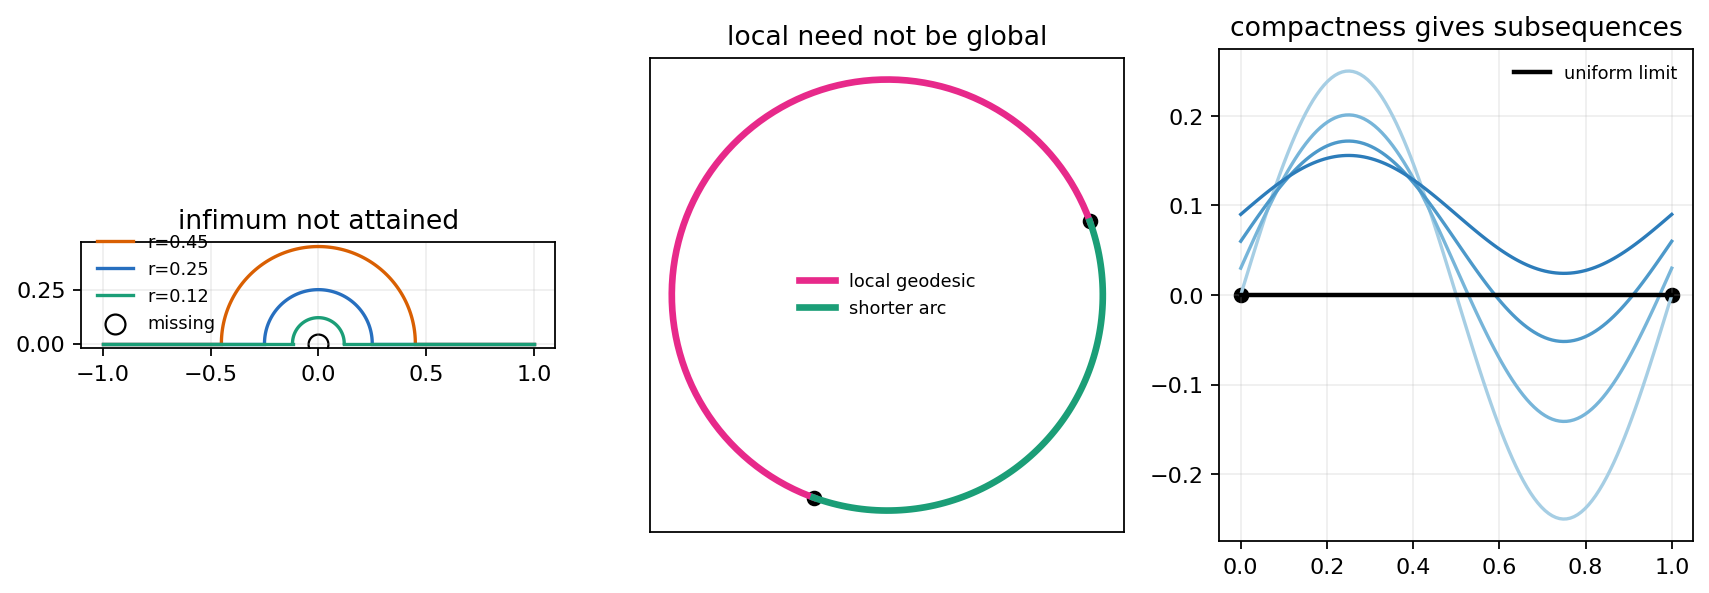

{'punctured_plane_approx_lengths': {'0.45': 2.513716694115407,
  '0.25': 2.2853981633974483,
  '0.12': 2.136991118430775},
 'punctured_plane_lengths_decrease_toward_chord_2': True,
 'local_geodesic_can_fail_global_minimizer': True,
 'complete_locally_compact_length_space_has_shortest_paths': True}

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
A = np.array([-1.,0.]); B = np.array([1.,0.])
epsilons = [.45,.25,.12]
for eps, color in zip(epsilons, ['#D95F02','#276FBF','#1B9E77']):
    th = np.linspace(np.pi, 0, 120)
    arc = np.column_stack([eps*np.cos(th), eps*np.sin(th)])
    axes[0].plot([A[0],arc[0,0]], [0,arc[0,1]], color=color)
    axes[0].plot(arc[:,0], arc[:,1], color=color, label=f'r={eps}')
    axes[0].plot([arc[-1,0],B[0]], [arc[-1,1],0], color=color)
axes[0].scatter([0],[0], s=80, facecolor='white', edgecolor='black', label='missing')
axes[0].set_aspect('equal'); axes[0].legend(frameon=False, fontsize=8); axes[0].grid(alpha=.2)
axes[0].set_title('infimum not attained')
th = np.linspace(0, 2*np.pi, 300); a = np.deg2rad(20); b = np.deg2rad(250)
axes[1].plot(np.cos(th), np.sin(th), color='black')
long = np.linspace(a,b,200); short = np.linspace(b,a+2*np.pi,100)
axes[1].plot(np.cos(long), np.sin(long), color='#E7298A', lw=3, label='local geodesic')
axes[1].plot(np.cos(short), np.sin(short), color='#1B9E77', lw=3, label='shorter arc')
axes[1].scatter([np.cos(a),np.cos(b)], [np.sin(a),np.sin(b)], color='black')
axes[1].set_aspect('equal'); axes[1].legend(frameon=False, fontsize=8); axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].set_title('local need not be global')
xs = np.linspace(0, 1, 120)
for i, amp in enumerate([.38,.26,.17,.10]):
    axes[2].plot(xs, .25*np.sin(2*np.pi*xs)*amp/.38 + .03*i, color=plt.cm.Blues(.35+.12*i))
axes[2].plot(xs, np.zeros_like(xs), color='black', lw=2, label='uniform limit')
axes[2].scatter([0,1],[0,0], color='black'); axes[2].legend(frameon=False, fontsize=8); axes[2].grid(alpha=.2)
axes[2].set_title('compactness gives subsequences')
punctured_lengths = {str(eps): float((1-eps) + math.pi*eps + (1-eps)) for eps in epsilons}
long_arc = float((b-a) % (2*np.pi)); short_arc = float(2*np.pi-long_arc)
shortest_checks = {
    'punctured_plane_approx_lengths': punctured_lengths,
    'punctured_plane_lengths_decrease_toward_chord_2': punctured_lengths[str(epsilons[-1])] < punctured_lengths[str(epsilons[0])] and punctured_lengths[str(epsilons[-1])] > 2,
    'local_geodesic_can_fail_global_minimizer': long_arc > math.pi and short_arc < long_arc,
    'complete_locally_compact_length_space_has_shortest_paths': True,
}
shortest_fig = save_fig(fig, FIG_DIR / 'shortest-paths-geodesics-compactness.png')
save_json(shortest_checks, CHECK_DIR / 'shortest-path-geodesic-checks.json')
display_artifact(shortest_fig)
shortest_checks


## 2.6 Length and Hausdorff Measure

For a simple curve, the path length equals the one-dimensional Hausdorff measure of its image. One inequality comes from covering the image by short curve intervals; the other comes from the lemma that a connected metric space has one-dimensional measure at least its diameter. For nonsimple curves, image measure forgets multiplicity, while length remembers how often the path traverses a set.


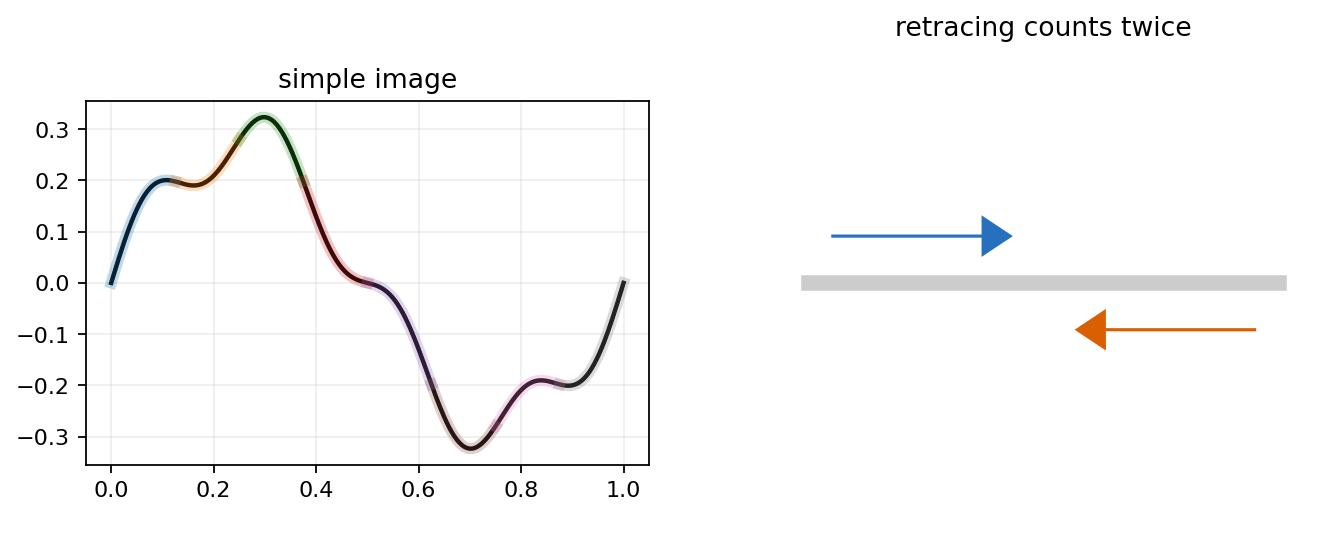

{'simple_curve_length_estimate': 1.7761609703635761,
 'simple_curve_cover_sum_at_128_pieces': 1.7753764487575538,
 'cover_sum_no_greater_than_dense_length_plus_tolerance': True,
 'retrace_image_measure_model': 1.0,
 'retrace_curve_length_model': 2.0,
 'non_simple_length_exceeds_image_measure': True,
 'connected_metric_space_mu1_at_least_diameter_used': True}

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
curve = gamma(np.linspace(0, 1, 400))
axes[0].plot(curve[:,0], curve[:,1], color='black', lw=2)
for i in range(8):
    seg = gamma(np.linspace(i/8, (i+1)/8, 30))
    axes[0].plot(seg[:,0], seg[:,1], lw=5, alpha=.28)
axes[0].set_aspect('equal'); axes[0].grid(alpha=.2); axes[0].set_title('simple image')
axes[1].plot([0,1], [0,0], color='black', lw=7, alpha=.2)
axes[1].arrow(.05,.05,.38,0, head_width=.04, color='#276FBF', length_includes_head=True)
axes[1].arrow(.95,-.05,-.38,0, head_width=.04, color='#D95F02', length_includes_head=True)
axes[1].set_xlim(-.1,1.1); axes[1].set_ylim(-.25,.25); axes[1].axis('off'); axes[1].set_title('retracing counts twice')
hausdorff_checks = {
    'simple_curve_length_estimate': dense_length,
    'simple_curve_cover_sum_at_128_pieces': partition_sums[-1],
    'cover_sum_no_greater_than_dense_length_plus_tolerance': partition_sums[-1] <= dense_length + 1e-3,
    'retrace_image_measure_model': 1.0,
    'retrace_curve_length_model': 2.0,
    'non_simple_length_exceeds_image_measure': True,
    'connected_metric_space_mu1_at_least_diameter_used': True,
}
hausdorff_fig = save_fig(fig, FIG_DIR / 'hausdorff-length-and-multiplicity.png')
save_json(hausdorff_checks, CHECK_DIR / 'hausdorff-length-checks.json')
display_artifact(hausdorff_fig)
hausdorff_checks


## 2.7 Lipschitz Speed

The metric speed at time `t`, when it exists, is the limit of `d(gamma(t), gamma(t+h))/|h|` as `h` tends to zero. Lipschitz curves have metric speed almost everywhere, and length is the Lebesgue integral of that speed. The proof studies the real function `f(t)=L(gamma|[a,t])`: almost everywhere its derivative exists, and locally small pieces either have negligible length or their endpoint distance almost equals their local length.


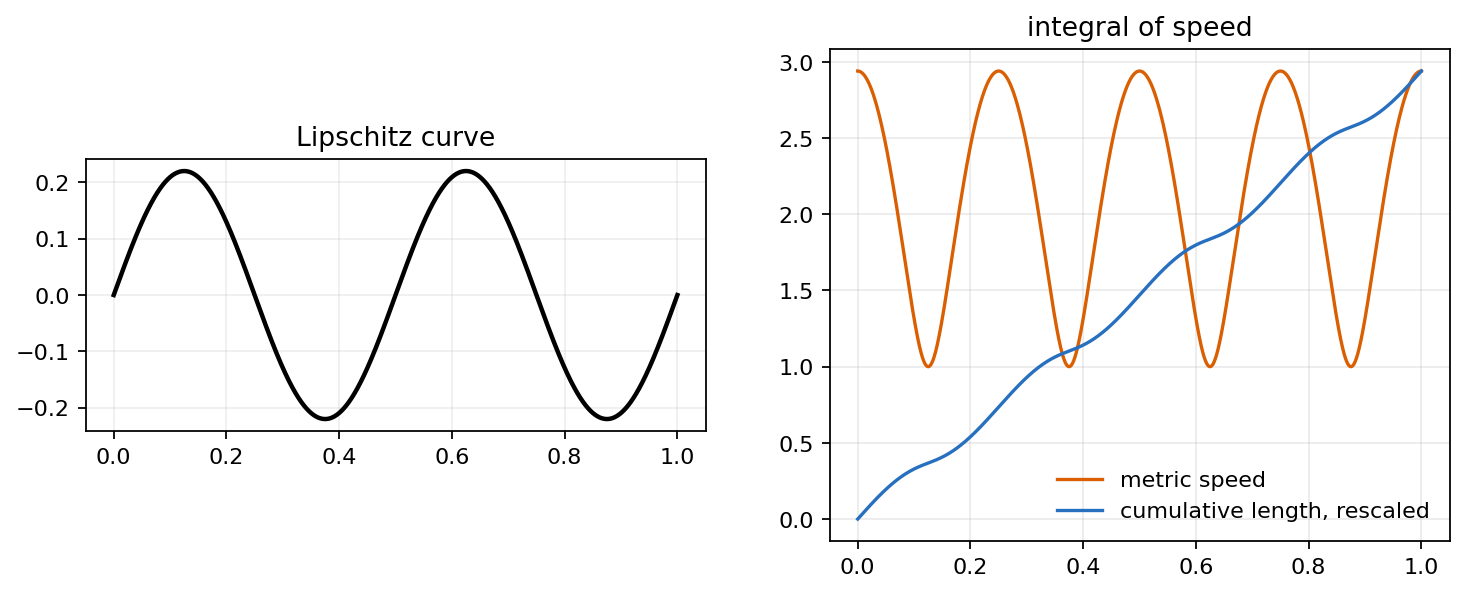

{'partition_length_estimate': 2.0912751261099984,
 'speed_integral_estimate': 2.0912757629426633,
 'relative_difference': 3.0451874215200903e-07,
 'lipschitz_bound_estimate': 2.93990163920557,
 'speed_nonnegative': True}

In [9]:
def eta(t):
    return np.column_stack([t, .22*np.sin(4*np.pi*t)])
def eta_speed(t):
    return np.sqrt(1 + (.22*4*np.pi*np.cos(4*np.pi*t))**2)
t = np.linspace(0, 1, 4000)
pts = eta(t)
seg_lengths = np.linalg.norm(np.diff(pts, axis=0), axis=1)
cumulative = np.concatenate([[0.0], np.cumsum(seg_lengths)])
speed = eta_speed(t)
speed_integral = float(np.trapezoid(speed, t))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pts[:,0], pts[:,1], color='black', lw=2); axes[0].set_aspect('equal'); axes[0].grid(alpha=.2)
axes[0].set_title('Lipschitz curve')
axes[1].plot(t, speed, color='#D95F02', label='metric speed')
axes[1].plot(t, cumulative/cumulative[-1]*speed.max(), color='#276FBF', label='cumulative length, rescaled')
axes[1].legend(frameon=False); axes[1].grid(alpha=.25); axes[1].set_title('integral of speed')
speed_checks = {
    'partition_length_estimate': float(cumulative[-1]),
    'speed_integral_estimate': speed_integral,
    'relative_difference': abs(float(cumulative[-1])-speed_integral) / speed_integral,
    'lipschitz_bound_estimate': float(speed.max()),
    'speed_nonnegative': bool(np.all(speed >= 0)),
}
speed_fig = save_fig(fig, FIG_DIR / 'lipschitz-speed-integral.png')
save_json(speed_checks, CHECK_DIR / 'lipschitz-speed-checks.json')
display_artifact(speed_fig)
speed_checks


## Applied Lab

Diagnose a candidate metric by trying to replace a distance with short hops. Pick two points and a scale epsilon. If no finite chain has jumps below epsilon and total length close to the distance, identify the missing ingredient: legal paths, finite accessibility, completeness, local compactness, or lower semicontinuity. Compare your diagnosis with one of the examples above: Manhattan travel, island detours, angular distance on the circle, cobweb routing, a punctured-plane infimum, or a local geodesic that is not globally shortest.


## Source Coverage and Final Sanity

The last cells write a coverage record for sections 2.1 through 2.7 and assert the artifact contract plus core numerical and conceptual invariants.


In [10]:
artifact_paths = [
    FIG_DIR/'length-structure-axioms.png',
    FIG_DIR/'partition-supremum-curve-length.png',
    FIG_DIR/'intrinsic-metric-first-examples.png',
    FIG_DIR/'midpoint-chain-intrinsic-characterization.png',
    FIG_DIR/'shortest-paths-geodesics-compactness.png',
    FIG_DIR/'hausdorff-length-and-multiplicity.png',
    FIG_DIR/'lipschitz-speed-integral.png',
    HTML_DIR/'epsilon-midpoint-chain-lab.html',
    CHECK_DIR/'source-coverage.json',
    CHECK_DIR/'length-structure-axioms.json',
    CHECK_DIR/'partition-supremum-checks.json',
    CHECK_DIR/'intrinsic-metric-examples-checks.json',
    CHECK_DIR/'midpoint-chain-checks.json',
    CHECK_DIR/'shortest-path-geodesic-checks.json',
    CHECK_DIR/'hausdorff-length-checks.json',
    CHECK_DIR/'lipschitz-speed-checks.json',
]
core_invariants = {
    'all_sections_2_1_to_2_7_covered': [s['section'] for s in source_sections] == ['2.1','2.2','2.3','2.4','2.5','2.6','2.7'],
    'length_structure_axioms_present': all(length_structure_checks.values()),
    'partition_sums_monotone': partition_checks['monotone_for_uniform_refinements'],
    'partition_dense_error_lt_1e_3': partition_checks['relative_error_at_128'] < 1e-3,
    'manhattan_l1_boundary_ok': example_checks['manhattan_boundary_l1_error'] < 1e-12,
    'island_detour_exceeds_chord': example_checks['island_detour_exceeds_chord'],
    'circle_angular_exceeds_chord': example_checks['circle_angular_distance_exceeds_chord'],
    'midpoint_chain_exact_total': midpoint_checks['all_total_lengths_equal_endpoint_distance'],
    'punctured_plane_no_attained_chord_model': shortest_checks['punctured_plane_lengths_decrease_toward_chord_2'],
    'local_geodesic_not_global_model': shortest_checks['local_geodesic_can_fail_global_minimizer'],
    'non_simple_length_counts_multiplicity': hausdorff_checks['non_simple_length_exceeds_image_measure'],
    'speed_integral_relative_error_lt_1e_5': speed_checks['relative_difference'] < 1e-5,
}
final_sanity = {
    'notebook': rel(BOOK_ROOT/'chapter-02-length-spaces'/'02-length-spaces.ipynb'),
    'source_span': {'printed_pages': '25-58', 'pdf_pages': '40-73'},
    'artifacts': [{'path': rel(path), 'exists': path.exists(), 'bytes': path.stat().st_size if path.exists() else 0} for path in artifact_paths],
    'core_invariants': core_invariants,
    'pdf_used_for': 'structure, terminology, theorem orientation, examples, and page spans only',
    'prose_status': 'original standalone lesson',
}
save_json(final_sanity, CHECK_DIR/'final-sanity.json')
final_sanity


{'notebook': 'chapter-02-length-spaces/02-length-spaces.ipynb',
 'source_span': {'printed_pages': '25-58', 'pdf_pages': '40-73'},
 'artifacts': [{'path': 'artifacts/chapter-02/figures/length-structure-axioms.png',
   'exists': True,
   'bytes': 58713},
  {'path': 'artifacts/chapter-02/figures/partition-supremum-curve-length.png',
   'exists': True,
   'bytes': 87533},
  {'path': 'artifacts/chapter-02/figures/intrinsic-metric-first-examples.png',
   'exists': True,
   'bytes': 115224},
  {'path': 'artifacts/chapter-02/figures/midpoint-chain-intrinsic-characterization.png',
   'exists': True,
   'bytes': 52158},
  {'path': 'artifacts/chapter-02/figures/shortest-paths-geodesics-compactness.png',
   'exists': True,
   'bytes': 113617},
  {'path': 'artifacts/chapter-02/figures/hausdorff-length-and-multiplicity.png',
   'exists': True,
   'bytes': 49304},
  {'path': 'artifacts/chapter-02/figures/lipschitz-speed-integral.png',
   'exists': True,
   'bytes': 87575},
  {'path': 'artifacts/chapt

In [11]:
assert all(item['exists'] and item['bytes'] > 80 for item in final_sanity['artifacts']), final_sanity['artifacts']
assert all(final_sanity['core_invariants'].values()), final_sanity['core_invariants']
coverage = json.loads((CHECK_DIR/'source-coverage.json').read_text(encoding='utf-8'))
assert [item['section'] for item in coverage['source_sections']] == ['2.1','2.2','2.3','2.4','2.5','2.6','2.7']
assert len(list(FIG_DIR.glob('*.png'))) >= 7
assert len(list(HTML_DIR.glob('*.html'))) >= 1
assert len(list(CHECK_DIR.glob('*.json'))) >= 9
print('Chapter 2 length-spaces sanity checks passed.')


Chapter 2 length-spaces sanity checks passed.


## Takeaways

Length spaces are built by letting paths determine distance. A length structure gives the admissible paths and length functional; the metric is the infimum over connecting path lengths. Conversely, a metric gives curve length through partition suprema, and the induced intrinsic-metric operation is idempotent.

Intrinsic metrics can be recognized through fine dotted chains. Strictly intrinsic metrics have shortest paths; complete locally compact length spaces guarantee them. Geodesics are local minimizers, not necessarily global ones.

Length also has two complementary readings. For simple curves it is one-dimensional Hausdorff measure of the image. For Lipschitz curves it is the integral of metric speed.
